In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression, Ridge

Neste código, começarei pela regressão logística e irei depois fazer o probit.

# 1) Regressão logística

In [21]:
teste = pd.read_csv('final_data/teste.csv')
treino = pd.read_csv('final_data/treino.csv')

teste0 = sm.add_constant(teste)

Em um primeiro momento, fiz o modelo geral para conhece-lo melhor.

In [22]:
X1 = treino.drop('SeriousDlqin2yrs', axis=1)
y = treino['SeriousDlqin2yrs']

X1 = sm.add_constant(X1)
logit_model1 = sm.Logit(y, X1)
logit_result1 = logit_model1.fit()

teste1 = teste0.drop(teste0.columns[[1]], axis=1)

df_t = pd.DataFrame({
    'real': teste['SeriousDlqin2yrs'],
    'Logit1': logit_result1.predict(teste1)
})
print(logit_result1.summary())

Optimization terminated successfully.
         Current function value: 0.226453
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               146076
Model:                          Logit   Df Residuals:                   146065
Method:                           MLE   Df Model:                           10
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.08277
Time:                        23:19:25   Log-Likelihood:                -33079.
converged:                       True   LL-Null:                       -36064.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.3376      0.0

Há 2 variáveis com valor-P maior que .01. Para o `segundo` modelo, retirarei estas variáveis.

In [23]:
X2 = X1.drop(X1.columns[[1,6]], axis=1)

Logit_model2 = sm.Logit(y, X2)
logit_result2 = Logit_model2.fit()

teste2 = teste1.drop(teste1.columns[[1,6]],axis=1)

df_t['Logit2'] = logit_result2.predict(teste2)
print(logit_result2.summary())

Optimization terminated successfully.
         Current function value: 0.226480
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               146076
Model:                          Logit   Df Residuals:                   146067
Method:                           MLE   Df Model:                            8
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.08266
Time:                        23:19:25   Log-Likelihood:                -33083.
converged:                       True   LL-Null:                       -36064.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.3559      0.0

Me baseando no gráfico de correlações feito em *ml_project*, Percebi que poderia haver um `problema` com `variáveis altamente correlacionadas`. Haviam particularmente 3 variáveis com correlação 2 a 2 maior que .98, tentei fazer um `modelo excluindo 2 delas` e enfim fiz uma primeira avaliação.

In [24]:
X3 = X2.drop(X2.columns[[5,7]],axis=1)

X3.head()

Logit_model3 = sm.Logit(y, X3)
Logit_result3 = Logit_model3.fit()

print(Logit_result3.summary())

teste3 = teste2.drop(teste2.columns[[5,7]], axis=1)

df_t['Logit3'] = Logit_result3.predict(teste3)

Optimization terminated successfully.
         Current function value: 0.236471
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               146076
Model:                          Logit   Df Residuals:                   146069
Method:                           MLE   Df Model:                            6
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.04219
Time:                        23:19:26   Log-Likelihood:                -34543.
converged:                       True   LL-Null:                       -36064.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.1362      0.0

In [25]:
Aval = pd.DataFrame({
    'Modelo': ['Logit 1', 'Logit 2', 'Logit 3'],
    'MSE': [
        mean_squared_error(df_t['real'], df_t['Logit1']),
        mean_squared_error(df_t['real'], df_t['Logit2']),
        mean_squared_error(df_t['real'], df_t['Logit3'])
    ],
    'MAE': [
        mean_absolute_error(df_t['real'], df_t['Logit1']),
        mean_absolute_error(df_t['real'], df_t['Logit2']),
        mean_absolute_error(df_t['real'], df_t['Logit3'])
    ],
    'Corr (Pearson)': [
        df_t['real'].corr(df_t['Logit1']),
        df_t['real'].corr(df_t['Logit2']),
        df_t['real'].corr(df_t['Logit3'])
    ]

})

Aval.head(3)

,Modelo,MSE,MAE,Corr (Pearson)
0,Logit 1,0.008092,0.051911,0.582204
1,Logit 2,0.008107,0.051938,0.581166
2,Logit 3,0.011093,0.063111,0.321067


Claramente a tentativa de contornar a alta correlação de variáveis falhou. Em uma segunda tentativa, optei por ao invés de simplesmente remover 2 preditores, remover 1 e adicionar um `termo de interação` entre os 2 restantes.

Segue uma descrição de qual variável foi retirada em qual:
 - Modelo 4: NumberOfTimes90DaysLate
 - Modelo 5: NumberOfTime30-59DaysPastDueNotWorse
 - Modelo 6: NumberOfTime60-89DaysPastDueNotWorse

Fiz um modelo diferente deu melhor que os demais, o modelo remove:
 - modelo 7: NumberRealEstateLoansOrLines

E então, como o modelo 7 tem todas as variáveis que gostaria de trabalhar experimentei fazer um termo de interação 2 a 2 e outro com um termo dos 3 simultaneamente:
 - modelo 8: todos os termos de interação 2 a 2
 - modelo 9: todos os termos de interação 2 a 2 e dos 3

In [26]:
#modelo 4
X4 = X2.drop(X2.columns[[5]],axis=1)
teste4 = teste2.drop(teste2.columns[[5]],axis=1)
X4['interaction_term'] = X4.iloc[:,2] * X4.iloc[:,6]
teste4['interaction_term'] = teste4.iloc[:,2] * teste4.iloc[:,6]

logit_model4 = sm.Logit(y, X4)
Logit_result4 = logit_model4.fit()
df_t['Logit4'] = Logit_result4.predict(teste4)

#modelo 5
X5 = X2.drop(X2.columns[[2]],axis=1)
teste5 = teste2.drop(teste2.columns[[2]],axis=1)
X5['interaction_term'] = X5.iloc[:,4] * X5.iloc[:,6]
teste5['interaction_term'] = teste5.iloc[:,4] * teste5.iloc[:,6]

Logit_mode5 = sm.Logit(y, X5)
Logit_result5 = Logit_mode5.fit()
df_t['Logit5'] = Logit_result5.predict(teste5)

#modelo 6
X6 = X2.drop(X2.columns[[7]],axis=1)
teste6 = teste2.drop(teste2.columns[[7]],axis=1)
X6['interaction_term'] = X6.iloc[:,2] * X6.iloc[:,5]
teste6['interaction_term'] = teste6.iloc[:,2] * teste6.iloc[:,5]

Logit_mode6 = sm.Logit(y, X6)
Logit_result6 = Logit_mode6.fit()
df_t['Logit6'] = Logit_result6.predict(teste6)

#modelo 7
X7 = X2.drop(X2.columns[[6]],axis=1)
teste7 = teste2.drop(teste2.columns[[6]],axis=1)
X7['interaction_term'] = X7.iloc[:,2] * X7.iloc[:,5]
teste7['interaction_term'] = teste7.iloc[:,2] * teste7.iloc[:,5]

Logit_mode7 = sm.Logit(y, X7)
Logit_result7 = Logit_mode7.fit()
df_t['Logit7'] = Logit_result7.predict(teste7)

#modelo 8
X8 = X7
teste8 = teste7
X8['interaction_term2'] = X8.iloc[:,2] * X8.iloc[:,6]
teste8['interaction_term2'] = teste8.iloc[:,2] * teste8.iloc[:,6]
X8['interaction_term3'] = X8.iloc[:,5] * X8.iloc[:,6]
teste8['interaction_term3'] = teste8.iloc[:,5] * teste8.iloc[:,6]

Logit_mode8 = sm.Logit(y, X8)
Logit_result8 = Logit_mode8.fit()
df_t['Logit8'] = Logit_result8.predict(teste8)

#modelo 9
X9 = X8
teste9 = teste8
X9['interaction_term4'] = X9.iloc[:,6] * X9.iloc[:,8]
teste9['interaction_term4'] = teste9.iloc[:,6] * teste9.iloc[:,8]

Logit_mode9 = sm.Logit(y, X9)
Logit_result9 = Logit_mode9.fit()
df_t['Logit9'] = Logit_result9.predict(teste9)

Optimization terminated successfully.
         Current function value: 0.210149
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.208443
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.203559
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.200236
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.199908
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.199447
         Iterations 8


In [27]:
n = len(df_t)

def adjusted_r2(y, yhat, p): #usando o R^2 pois cada modelo tem um número diferente de preditores
    if n - p - 1 <= 0:
        return float('nan')
    r2 = r2_score(y, yhat)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

p1 = X1.shape[1] - 1
p2 = X2.shape[1] - 1
p3 = X3.shape[1] - 1
p4 = X4.shape[1] - 1
p5 = X5.shape[1] - 1
p6 = X6.shape[1] - 1
p7 = X7.shape[1] - 1
p8 = X8.shape[1] - 1
p9 = X9.shape[1] - 1


Aval = pd.DataFrame({
    'Modelo': ['Logit 1', 'Logit 2', 'Logit 3', 'Logit 4', 'Logit 5', 'Logit 6','Logit 7', 'Logit 8', 'Logit 9'],
    'MSE': [
        mean_squared_error(df_t['real'], df_t['Logit1']),
        mean_squared_error(df_t['real'], df_t['Logit2']),
        mean_squared_error(df_t['real'], df_t['Logit3']),
        mean_squared_error(df_t['real'], df_t['Logit4']),
        mean_squared_error(df_t['real'], df_t['Logit5']),
        mean_squared_error(df_t['real'], df_t['Logit6']),
        mean_squared_error(df_t['real'], df_t['Logit7']),
        mean_squared_error(df_t['real'], df_t['Logit8']),
        mean_squared_error(df_t['real'], df_t['Logit9'])
    ],
    'MAE': [
        mean_absolute_error(df_t['real'], df_t['Logit1']),
        mean_absolute_error(df_t['real'], df_t['Logit2']),
        mean_absolute_error(df_t['real'], df_t['Logit3']),
        mean_absolute_error(df_t['real'], df_t['Logit4']),
        mean_absolute_error(df_t['real'], df_t['Logit5']),
        mean_absolute_error(df_t['real'], df_t['Logit6']),
        mean_absolute_error(df_t['real'], df_t['Logit7']),
        mean_absolute_error(df_t['real'], df_t['Logit8']),
        mean_absolute_error(df_t['real'], df_t['Logit9'])
    ],
    'Corr (Pearson)': [
        df_t['real'].corr(df_t['Logit1']),
        df_t['real'].corr(df_t['Logit2']),
        df_t['real'].corr(df_t['Logit3']),
        df_t['real'].corr(df_t['Logit4']),
        df_t['real'].corr(df_t['Logit5']),
        df_t['real'].corr(df_t['Logit6']),
        df_t['real'].corr(df_t['Logit7']),
        df_t['real'].corr(df_t['Logit8']),
        df_t['real'].corr(df_t['Logit9'])
    ],
    'Adj R2': [
        adjusted_r2(df_t['real'], df_t['Logit1'], p1),
        adjusted_r2(df_t['real'], df_t['Logit2'], p2),
        adjusted_r2(df_t['real'], df_t['Logit3'], p3),
        adjusted_r2(df_t['real'], df_t['Logit4'], p4),
        adjusted_r2(df_t['real'], df_t['Logit5'], p5),
        adjusted_r2(df_t['real'], df_t['Logit6'], p6),
        adjusted_r2(df_t['real'], df_t['Logit7'], p7),
        adjusted_r2(df_t['real'], df_t['Logit8'], p8),
        adjusted_r2(df_t['real'], df_t['Logit9'], p9)
    ]

})

Aval.head(9)

,Modelo,MSE,MAE,Corr (Pearson),Adj R2
0,Logit 1,0.008092,0.051911,0.582204,0.338813
1,Logit 2,0.008107,0.051938,0.581166,0.337605
2,Logit 3,0.011093,0.063111,0.321067,0.093661
3,Logit 4,0.006209,0.043532,0.713994,0.492679
4,Logit 5,0.005113,0.043544,0.772148,0.582246
5,Logit 6,0.004621,0.039192,0.799707,0.622441
6,Logit 7,0.003896,0.036786,0.836698,0.681713
7,Logit 8,0.003836,0.036440,0.839227,0.686558
8,Logit 9,0.003578,0.035288,0.850025,0.707639


Por fim, o modelo 9 apresentou os melhores resultados. Segue uma visualização interessante da distribuição da diferença em módulo do *y* real e do previsto pelo modelo:

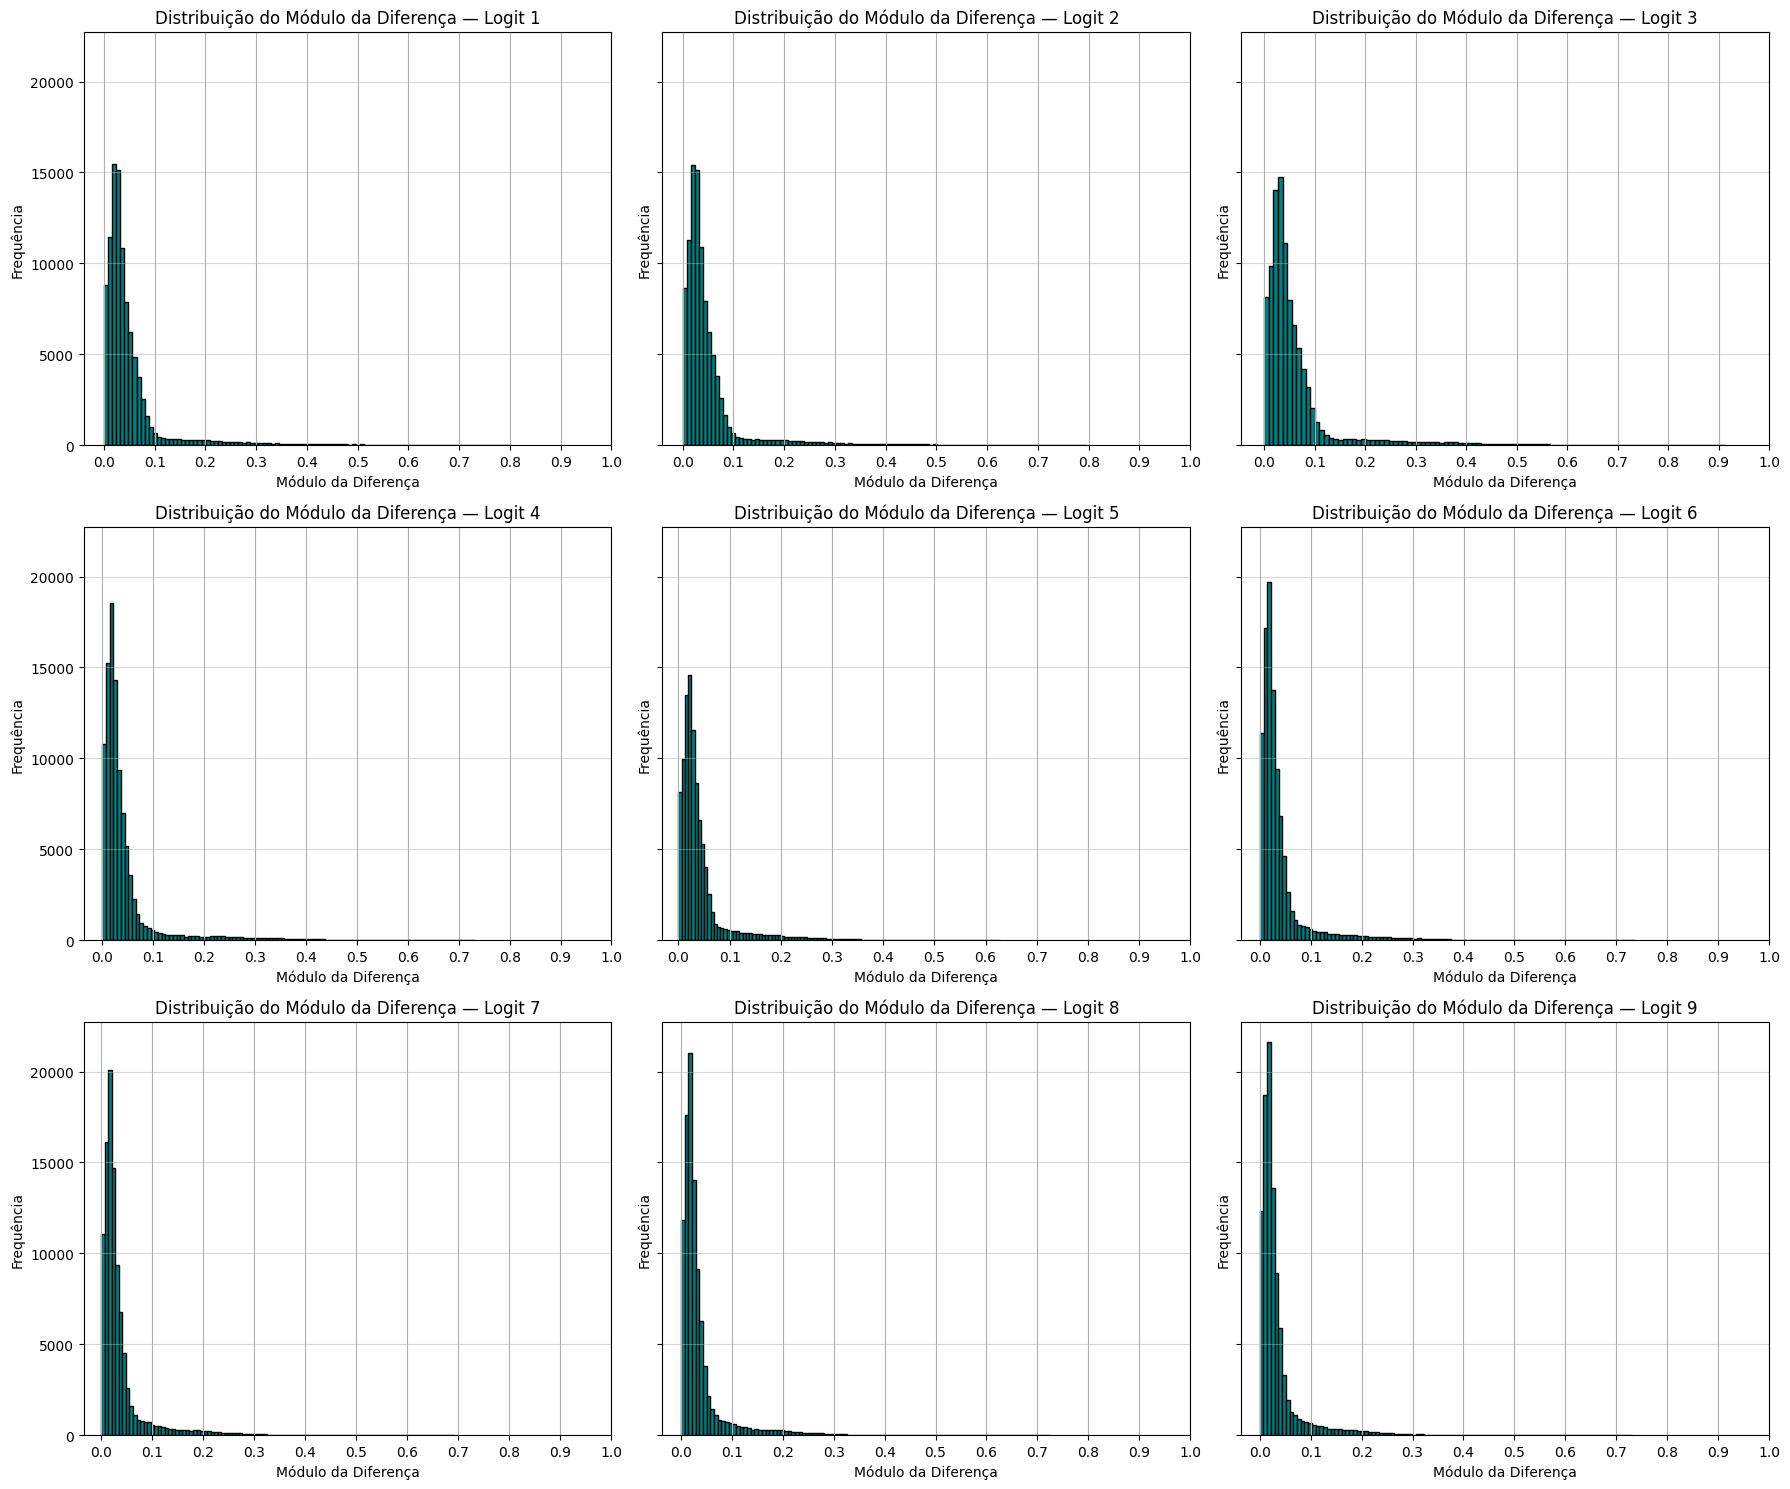

In [28]:
df_t["abs_diff1"] = (df_t["Logit1"] - df_t["real"]).abs()
df_t["abs_diff2"] = (df_t["Logit2"] - df_t["real"]).abs()
df_t["abs_diff3"] = (df_t["Logit3"] - df_t["real"]).abs()
df_t["abs_diff4"] = (df_t["Logit4"] - df_t["real"]).abs()
df_t["abs_diff5"] = (df_t["Logit5"] - df_t["real"]).abs()
df_t["abs_diff6"] = (df_t["Logit6"] - df_t["real"]).abs()
df_t["abs_diff7"] = (df_t["Logit7"] - df_t["real"]).abs()
df_t["abs_diff8"] = (df_t["Logit8"] - df_t["real"]).abs()
df_t["abs_diff9"] = (df_t["Logit9"] - df_t["real"]).abs()

fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharey=True)

cols = [("abs_diff1", "Logit 1"), ("abs_diff2", "Logit 2"), ("abs_diff3", "Logit 3"),
        ("abs_diff4", "Logit 4"), ("abs_diff5", "Logit 5"), ("abs_diff6", "Logit 6"),
        ("abs_diff7", "Logit 7"), ("abs_diff8", "Logit 8"), ("abs_diff9", "Logit 9")]
for ax, (col, label) in zip(axes.flatten(), cols):
    df_t[col].hist(bins=100, edgecolor='black', color='teal', ax=ax)
    ax.set_title(f'Distribuição do Módulo da Diferença — {label}', fontsize=12)
    ax.set_xlabel('Módulo da Diferença')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.5)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

plt.tight_layout()
plt.show()

Em uma última tentativa de melhorar os resultados, fiz uma `regularização` após verificar que o modelo estava com `alta variância` via *VIF*

In [29]:
vif_data = pd.DataFrame({
    'feature': X9.columns,
    'VIF': [variance_inflation_factor(X9.values, i) for i in range(X9.shape[1])]
})
print(vif_data)

                                 feature            VIF
0                                  const      16.525454
1                                    age       1.062365
2   NumberOfTime30-59DaysPastDueNotWorse      44.568622
3                              DebtRatio       1.002462
4                          MonthlyIncome       1.009221
5                NumberOfTimes90DaysLate     110.468221
6   NumberOfTime60-89DaysPastDueNotWorse     236.646778
7                     NumberOfDependents       1.060539
8                       interaction_term  398557.693798
9                      interaction_term2  450380.263200
10                     interaction_term3  448623.737997
11                     interaction_term4  116260.662771


variáveis com *VIF* maior que 100 tem alta colinearidade, então farei uma regularização para tentar contornar este possível problema. Primeiro fiz um `cross validation` para identificar a melhor constante de penalização.

c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.91914e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.75947e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.69501e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.47119e-19): result may not be accurate.
  return linalg.solve

Best lambda: 200


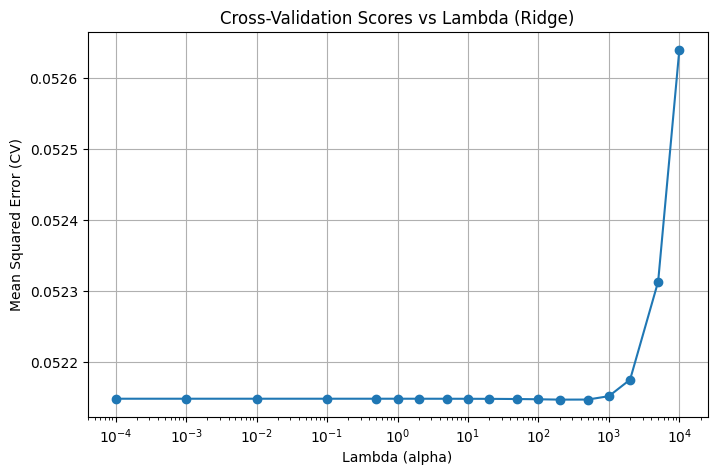

In [30]:
lam_list = [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

cv_scores = []

for lam in lam_list:
    ridge = Ridge(alpha=lam)
    scores = cross_val_score(ridge, X9, y, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

best_lam = lam_list[np.argmin(cv_scores)]
print("Best lambda:", best_lam)

plt.figure(figsize=(8,5))
plt.semilogx(lam_list, cv_scores, marker='o')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Mean Squared Error (CV)')
plt.title('Cross-Validation Scores vs Lambda (Ridge)')
plt.grid(True)
plt.show()

Os resultados mostram que o termo de penalização não ajuda a diminuir o erro. Porém, vou fazer o `ridge` para confirmar que não há melhora de resultado usando o valor da constante como o ótimo de 500.

In [31]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",        
        C=200.0,               
        solver="lbfgs",      
        max_iter=1000,
        random_state=42
    ))
])

for i, (train_index9, val_index9) in enumerate(kf.split(X9)):
    X9_train, X9_val = X9.iloc[train_index9], X9.iloc[val_index9]
    y_train, y_val = y.iloc[train_index9], y.iloc[val_index9]

    model.fit(X9_train, y_train)


    y_pred = model.predict(X9_val)
    y_proba = model.predict_proba(X9_val)[:, 1]

    auc_p = roc_auc_score(y_val, y_proba)

    # Treinar o modelo Logit
    logit_model = sm.Logit(y_train, X9_train)
    logit_model = logit_model.fit()

    # Prever probabilidades
    y_pred_proba = logit_model.predict(X9_val)
    # Calcular AUC
    auc = roc_auc_score(y_val, y_pred_proba)
    auc_scores.append(auc)


    print(f"Fold {i+1}: AUC = {auc:.4f}")
    print(f"Fold {i+1}: AUC penalty = {auc_p:.4f}")


# AUC médio e desvio padrão
print("\nMédia do AUC (5 folds): {:.4f}".format(np.mean(auc_scores)))
print("Desvio padrão do AUC: {:.4f}".format(np.std(auc_scores)))

Optimization terminated successfully.
         Current function value: 0.199677
         Iterations 8
Fold 1: AUC = 0.8054
Fold 1: AUC penalty = 0.8033
Optimization terminated successfully.
         Current function value: 0.198759
         Iterations 8
Fold 2: AUC = 0.8180
Fold 2: AUC penalty = 0.8152
Optimization terminated successfully.
         Current function value: 0.200090
         Iterations 8
Fold 3: AUC = 0.8138
Fold 3: AUC penalty = 0.8112
Optimization terminated successfully.
         Current function value: 0.199495
         Iterations 8
Fold 4: AUC = 0.8128
Fold 4: AUC penalty = 0.8112
Optimization terminated successfully.
         Current function value: 0.199128
         Iterations 7
Fold 5: AUC = 0.8184
Fold 5: AUC penalty = 0.8167

Média do AUC (5 folds): 0.8137
Desvio padrão do AUC: 0.0047


De fato o `AUC` mostra não haver melhora de resultado.

# 2) Probit

O probit faz uma regressão linear e depois aplica uma função densidade acumulada da normal padrão. Em um primeiro momento, fiz o modelo geral para conhece-lo melhor.

In [32]:
X1 = treino.drop('SeriousDlqin2yrs', axis=1)
y = treino['SeriousDlqin2yrs']

X1 = sm.add_constant(X1)
Probit_model1 = sm.Probit(y, X1)
Probit_result1 = Probit_model1.fit()

teste1 = teste0.drop(teste0.columns[[1]],axis=1)

df_t = pd.DataFrame({
    'real': teste['SeriousDlqin2yrs'],
    'Probit1': Probit_result1.predict(teste1)
})
print(Probit_result1.summary())

Optimization terminated successfully.
         Current function value: 0.227962
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               146076
Model:                         Probit   Df Residuals:                   146065
Method:                           MLE   Df Model:                           10
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.07666
Time:                        23:19:37   Log-Likelihood:                -33300.
converged:                       True   LL-Null:                       -36064.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.8411      0.0

Há 3 variáveis com valor-P maior que .01. Para o `segundo` modelo, retirarei estas variáveis. (Diferentemente do logit, que haviam apenas 2 variáveis)

In [33]:
X2 = X1.drop(X1.columns[[1,4,6]], axis=1)

Probit_model2 = sm.Probit(y, X2)
Probit_result2 = Probit_model2.fit()

teste2 = teste1.drop(teste1.columns[[1,4,6]],axis=1)

df_t['Probit2'] = Probit_result2.predict(teste2)
print(Probit_result2.summary())

Optimization terminated successfully.
         Current function value: 0.228022
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               146076
Model:                         Probit   Df Residuals:                   146068
Method:                           MLE   Df Model:                            7
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.07641
Time:                        23:19:38   Log-Likelihood:                -33309.
converged:                       True   LL-Null:                       -36064.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.8527      0.0

Daqui em diante, o desenvolvimento será igual ao do logit. Irei condensar todo o desenvolvimento por ser apenas repetitivo. Mas segue uma descrição geral:
 - Modelo 3: remove _NumberOfTimes90DaysLate_ e _NumberOfTime60-89DaysPastDueNotWorse_
 - Modelo 4: remove NumberOfTimes90DaysLate
 - Modelo 5: remove NumberOfTime30-59DaysPastDueNotWorse
 - Modelo 6: remove NumberOfTime60-89DaysPastDueNotWorse
 - modelo 7: remove NumberRealEstateLoansOrLines
 - modelo 8: todos os termos de interação 2 a 2
 - modelo 9: todos os termos de interação 2 a 2 e dos 3

In [34]:
#modelo 3
X3 = X2.drop(X2.columns[[4,6]],axis=1)
teste3 = teste2.drop(teste2.columns[[4,6]], axis=1)

Probit_model3 = sm.Probit(y, X3)
Probit_result3 = Probit_model3.fit()
df_t['Probit3'] = Probit_result3.predict(teste3)

#modelo 4
X4 = X2.drop(X2.columns[[4]],axis=1)
teste4 = teste2.drop(teste2.columns[[4]],axis=1)
X4['interaction_term'] = X4.iloc[:,2] * X4.iloc[:,5]
teste4['interaction_term'] = teste4.iloc[:,2] * teste4.iloc[:,5]

Probit_model4 = sm.Probit(y, X4)
Probit_result4 = Probit_model4.fit()
df_t['Probit4'] = Probit_result4.predict(teste4)

#modelo 5
X5 = X2.drop(X2.columns[[2]],axis=1)
teste5 = teste2.drop(teste2.columns[[2]],axis=1)
X5['interaction_term'] = X5.iloc[:,3] * X5.iloc[:,5]
teste5['interaction_term'] = teste5.iloc[:,3] * teste5.iloc[:,5]

Probit_mode5 = sm.Probit(y, X5)
Probit_result5 = Probit_mode5.fit()
df_t['Probit5'] = Probit_result5.predict(teste5)

#modelo 6
X6 = X2.drop(X2.columns[[6]],axis=1)
teste6 = teste2.drop(teste2.columns[[6]],axis=1)
X6['interaction_term'] = X6.iloc[:,2] * X6.iloc[:,4]
teste6['interaction_term'] = teste6.iloc[:,2] * teste6.iloc[:,4]

Probit_mode6 = sm.Probit(y, X6)
Probit_result6 = Probit_mode6.fit()
df_t['Probit6'] = Probit_result6.predict(teste6)

#modelo 7
X7 = X2.drop(X2.columns[[5]],axis=1)
teste7 = teste2.drop(teste2.columns[[5]],axis=1)
X7['interaction_term'] = X7.iloc[:,2] * X7.iloc[:,4]
teste7['interaction_term'] = teste7.iloc[:,2] * teste7.iloc[:,4]

Probit_mode7 = sm.Probit(y, X7)
Probit_result7 = Probit_mode7.fit()
df_t['Probit7'] = Probit_result7.predict(teste7)

#modelo 8
X8 = X7
teste8 = teste7
X8['interaction_term2'] = X8.iloc[:,2] * X8.iloc[:,5]
teste8['interaction_term2'] = teste8.iloc[:,2] * teste8.iloc[:,5]
X8['interaction_term3'] = X8.iloc[:,4] * X8.iloc[:,5]
teste8['interaction_term3'] = teste8.iloc[:,4] * teste8.iloc[:,5]

Probit_mode8 = sm.Probit(y, X8)
Probit_result8 = Probit_mode8.fit()
df_t['Probit8'] = Probit_result8.predict(teste8)

#modelo 9
X9 = X8
teste9 = teste8
X9['interaction_term4'] = X9.iloc[:,2] * X9.iloc[:,4] * X9.iloc[:,5]
teste9['interaction_term4'] = teste9.iloc[:,2] * teste9.iloc[:,4] * X9.iloc[:,5]

Probit_mode9 = sm.Probit(y, X9)
Probit_result9 = Probit_mode9.fit()
df_t['Probit9'] = Probit_result9.predict(teste9)

Optimization terminated successfully.
         Current function value: 0.236185
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.209155
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.208103
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.202905
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.199160
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.198953
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.198646
         Iterations 7


In [35]:
n = len(df_t)

p1 = X1.shape[1] - 1
p2 = X2.shape[1] - 1
p3 = X3.shape[1] - 1
p4 = X4.shape[1] - 1
p5 = X5.shape[1] - 1
p6 = X6.shape[1] - 1
p7 = X7.shape[1] - 1
p8 = X8.shape[1] - 1
p9 = X9.shape[1] - 1

nds = pd.DataFrame({
    'Modelo': ['Probit 1', 'Probit 2', 'Probit 3', 'Probit 4', 'Probit 5', 'Probit 6', 'Probit 7', 'Probit 8', 'Probit 9'],
    'MSE': [
        mean_squared_error(df_t['real'], df_t['Probit1']),
        mean_squared_error(df_t['real'], df_t['Probit2']),
        mean_squared_error(df_t['real'], df_t['Probit3']),
        mean_squared_error(df_t['real'], df_t['Probit4']),
        mean_squared_error(df_t['real'], df_t['Probit5']),
        mean_squared_error(df_t['real'], df_t['Probit6']),
        mean_squared_error(df_t['real'], df_t['Probit7']),
        mean_squared_error(df_t['real'], df_t['Probit8']),
        mean_squared_error(df_t['real'], df_t['Probit9'])
    ],
    'MAE': [
        mean_absolute_error(df_t['real'], df_t['Probit1']),
        mean_absolute_error(df_t['real'], df_t['Probit2']),
        mean_absolute_error(df_t['real'], df_t['Probit3']),
        mean_absolute_error(df_t['real'], df_t['Probit4']),
        mean_absolute_error(df_t['real'], df_t['Probit5']),
        mean_absolute_error(df_t['real'], df_t['Probit6']),
        mean_absolute_error(df_t['real'], df_t['Probit7']),
        mean_absolute_error(df_t['real'], df_t['Probit8']),
        mean_absolute_error(df_t['real'], df_t['Probit9'])
    ],
    'Corr (Pearson)': [
        df_t['real'].corr(df_t['Probit1']),
        df_t['real'].corr(df_t['Probit2']),
        df_t['real'].corr(df_t['Probit3']),
        df_t['real'].corr(df_t['Probit4']),
        df_t['real'].corr(df_t['Probit5']),
        df_t['real'].corr(df_t['Probit6']),
        df_t['real'].corr(df_t['Probit7']),
        df_t['real'].corr(df_t['Probit8']),
        df_t['real'].corr(df_t['Probit9'])
    ],
    'Adj R2': [
        adjusted_r2(df_t['real'], df_t['Probit1'], p1),
        adjusted_r2(df_t['real'], df_t['Probit2'], p2),
        adjusted_r2(df_t['real'], df_t['Probit3'], p3),
        adjusted_r2(df_t['real'], df_t['Probit4'], p4),
        adjusted_r2(df_t['real'], df_t['Probit5'], p5),
        adjusted_r2(df_t['real'], df_t['Probit6'], p6),
        adjusted_r2(df_t['real'], df_t['Probit7'], p7),
        adjusted_r2(df_t['real'], df_t['Probit8'], p8),
        adjusted_r2(df_t['real'], df_t['Probit9'], p9)
    ]

})

nds.head(9)

,Modelo,MSE,MAE,Corr (Pearson),Adj R2
0,Probit 1,0.008495,0.053620,0.554068,0.305954
1,Probit 2,0.008498,0.053563,0.553835,0.305695
2,Probit 3,0.011041,0.062692,0.326147,0.097950
3,Probit 4,0.005933,0.042212,0.724784,0.515229
4,Probit 5,0.004895,0.042683,0.777059,0.600060
5,Probit 6,0.004378,0.038067,0.805633,0.642281
6,Probit 7,0.003610,0.035337,0.844548,0.705033
7,Probit 8,0.003574,0.035153,0.846124,0.707999
8,Probit 9,0.004012,0.035579,0.825332,0.672176


Vale comentar que o modelo com a interação dos 3 preditores simultaneamente foi boa para a regressão logística mas piorou os resultados de probit. Segue uma visualização dos resultados.

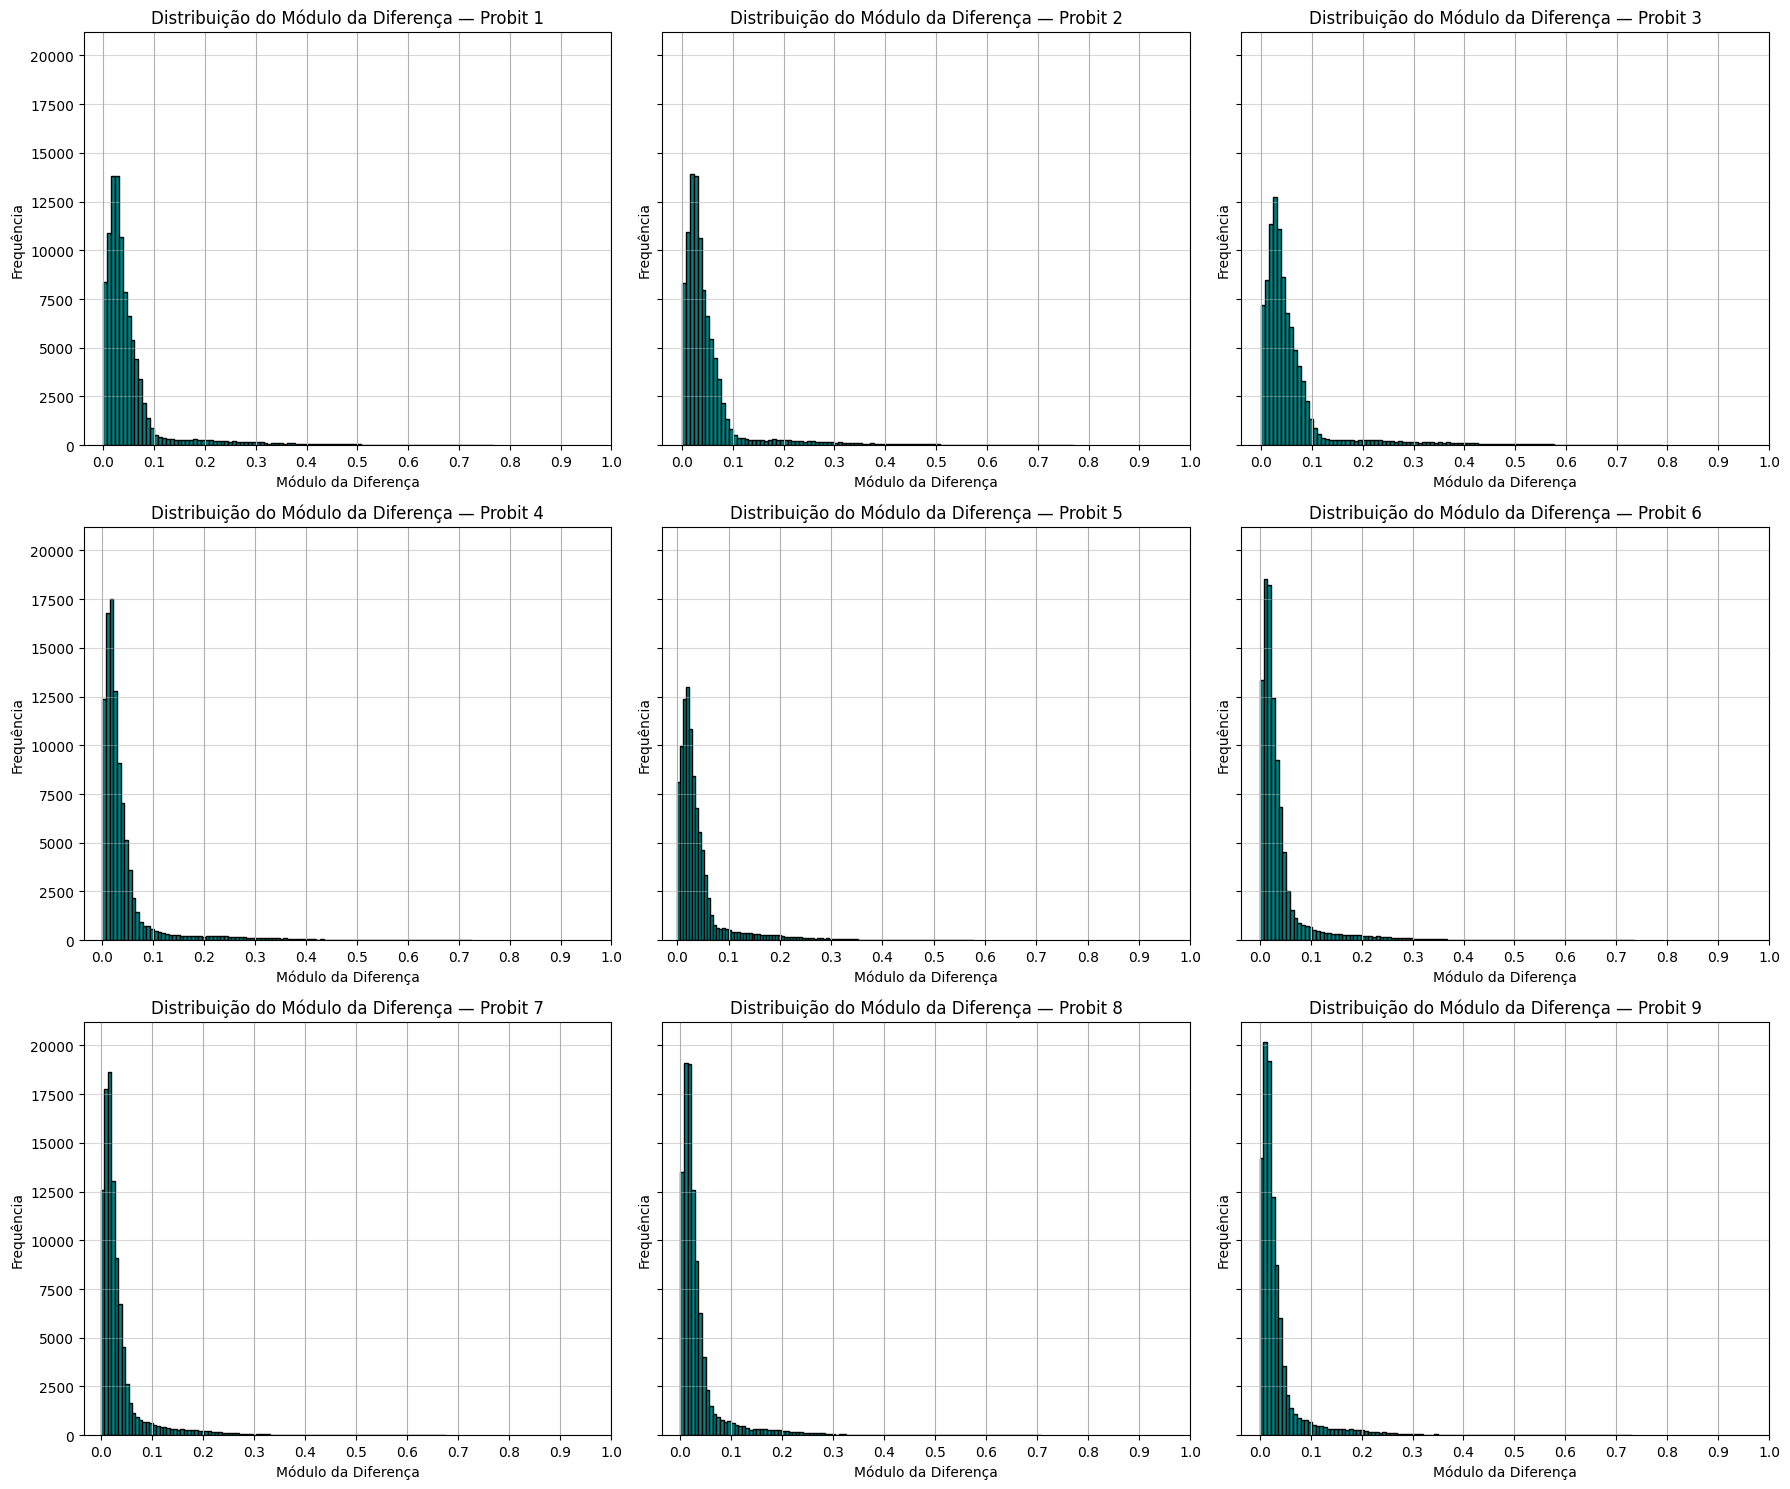

In [36]:
df_t["abs_diff1"] = (df_t["Probit1"] - df_t["real"]).abs()
df_t["abs_diff2"] = (df_t["Probit2"] - df_t["real"]).abs()
df_t["abs_diff3"] = (df_t["Probit3"] - df_t["real"]).abs()
df_t["abs_diff4"] = (df_t["Probit4"] - df_t["real"]).abs()
df_t["abs_diff5"] = (df_t["Probit5"] - df_t["real"]).abs()
df_t["abs_diff6"] = (df_t["Probit6"] - df_t["real"]).abs()
df_t["abs_diff7"] = (df_t["Probit7"] - df_t["real"]).abs()
df_t["abs_diff8"] = (df_t["Probit8"] - df_t["real"]).abs()
df_t["abs_diff9"] = (df_t["Probit9"] - df_t["real"]).abs()

fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharey=True)

cols = [("abs_diff1", "Probit 1"), ("abs_diff2", "Probit 2"), ("abs_diff3", "Probit 3"),
        ("abs_diff4", "Probit 4"), ("abs_diff5", "Probit 5"), ("abs_diff6", "Probit 6"),
        ("abs_diff7", "Probit 7"), ("abs_diff8", "Probit 8"), ("abs_diff9", "Probit 9")]
for ax, (col, label) in zip(axes.flatten(), cols):
    df_t[col].hist(bins=100, edgecolor='black', color='teal', ax=ax)
    ax.set_title(f'Distribuição do Módulo da Diferença — {label}', fontsize=12)
    ax.set_xlabel('Módulo da Diferença')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.5)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

plt.tight_layout()
plt.show()

Para fins de métricas, farei o AUC_ROC do melhor modelo:

In [38]:
random_state = 42
n = len(X8)
perm = np.random.RandomState(random_state).permutation(n)
split = int(n * 0.8)
train_idx, test_idx = perm[:split], perm[split:]

X8_train = X8.iloc[train_idx]
X8_test = X8.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

probit_model = sm.Probit(y_train, X8_train)
probit_result = probit_model.fit(disp=False)

y_pred_prob = probit_result.predict(X8_test)
auc = roc_auc_score(y_test, y_pred_prob)
print(f'AUC-ROC : {auc:.4f}')

AUC-ROC : 0.8180
